# Part 3 — Ekstraksi Fitur Audio: DAIC-WOZ
**Pipeline**: Klasifikasi Kesehatan Mental Berbasis Audio (DAIC-WOZ)
**Peran**: ML & Data Engineer — Athila Ramdani Saputra

Notebook ini bertugas untuk:
1. Menjalankan ulang preprocessing (Part 2) per partisipan
2. Mengekstrak fitur akustik: MFCC, Pitch, Energy, Spectral, ZCR
3. Mengagregasi fitur (mean, std, min, max, percentile) per partisipan
4. Menghasilkan `daic_features_raw.csv` (1 baris = 1 partisipan)

**Referensi**: Agbo et al. (2024), Yadav et al. (2023), Wu et al. (2024)


In [1]:
import os
import sys
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")


Library berhasil diimport.


## Konfigurasi Path


In [2]:
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.path.abspath(os.getcwd())

BASE_DIR      = os.path.dirname(os.path.dirname(current_dir))
DAIC_DIR      = os.path.join(BASE_DIR, 'dataset', 'raw', 'DAIC-WOZ')
PROCESSED_DIR = os.path.join(BASE_DIR, 'dataset', 'processed')
OUTPUT_DIR    = os.path.join(BASE_DIR, 'docs', 'assets', 'images', 'daic')
META_PATH     = os.path.join(PROCESSED_DIR, 'daic_metadata.csv')

TARGET_SR    = 16000
N_MFCC       = 13     # 13 koefisien MFCC (sesuai standar literatur)
FRAME_LENGTH = int(0.025 * TARGET_SR)  # 25ms window
HOP_LENGTH   = int(0.010 * TARGET_SR)  # 10ms hop

print(f"MFCC koefisien : {N_MFCC}")
print(f"Frame length   : {FRAME_LENGTH} samples ({FRAME_LENGTH/TARGET_SR*1000:.0f}ms)")
print(f"Hop length     : {HOP_LENGTH} samples ({HOP_LENGTH/TARGET_SR*1000:.0f}ms)")


MFCC koefisien : 13
Frame length   : 400 samples (25ms)
Hop length     : 160 samples (10ms)


## 3.1 — Impor Fungsi Preprocessing dari Part 2
Mendefinisikan ulang fungsi preprocessing agar Part 3 bersifat self-contained.


In [3]:
def get_participant_segments(transcript_path):
    """Filter segmen suara Participant dari TRANSCRIPT.csv."""
    try:
        df = pd.read_csv(transcript_path, sep='\t')
        df.columns = [c.strip().lower() for c in df.columns]
        df_p = df[df['speaker'].str.strip().str.lower() == 'participant']
        return list(zip(df_p['start_time'].astype(float), df_p['stop_time'].astype(float)))
    except Exception:
        return []

def extract_participant_audio(y, sr, segments, min_duration=0.3):
    """Gabungkan segmen audio Participant."""
    chunks = []
    for (start, stop) in segments:
        if (stop - start) < min_duration:
            continue
        s, e = int(start * sr), min(int(stop * sr), len(y))
        if s < e:
            chunks.append(y[s:e])
    return np.concatenate(chunks) if chunks else y

def apply_vad(y, sr, top_db=25):
    """VAD: hapus bagian hening."""
    if len(y) == 0:
        return y
    intervals = librosa.effects.split(y, top_db=top_db,
                                       frame_length=512, hop_length=128)
    if len(intervals) == 0:
        return y
    return np.concatenate([y[s:e] for s, e in intervals])

def normalize_audio(y):
    """Normalisasi amplitudo ke [-1, 1]."""
    max_amp = np.max(np.abs(y))
    return y / max_amp if max_amp > 0 else y

def load_and_preprocess(pid, folder_path, sr=TARGET_SR):
    """Load + preprocess lengkap (diarization + VAD + normalisasi)."""
    audio_path      = os.path.join(folder_path, f"{pid}_AUDIO.wav")
    transcript_path = os.path.join(folder_path, f"{pid}_TRANSCRIPT.csv")
    try:
        y, _ = librosa.load(audio_path, sr=sr, mono=True)
    except Exception as e:
        return None
    segments = get_participant_segments(transcript_path)
    if segments:
        y = extract_participant_audio(y, sr, segments)
    y = apply_vad(y, sr)
    return normalize_audio(y) if len(y) > 0 else None


## 3.2 — Fungsi: Agregasi Statistik
Setiap fitur level-frame diagregasi menjadi: mean, std, min, max, p25, p75.


In [4]:
def aggregate_feature(feat_array, name):
    """
    Mengagregasi array fitur 1D menjadi dict statistik.
    feat_array: 1D numpy array (nilai per frame)
    """
    if len(feat_array) == 0:
        return {f'{name}_mean': 0, f'{name}_std': 0, f'{name}_min': 0,
                f'{name}_max': 0, f'{name}_p25': 0, f'{name}_p75': 0}
    return {
        f'{name}_mean': float(np.mean(feat_array)),
        f'{name}_std' : float(np.std(feat_array)),
        f'{name}_min' : float(np.min(feat_array)),
        f'{name}_max' : float(np.max(feat_array)),
        f'{name}_p25' : float(np.percentile(feat_array, 25)),
        f'{name}_p75' : float(np.percentile(feat_array, 75)),
    }


## 3.3 — Fungsi: Ekstraksi Fitur Lengkap
Mengekstrak semua fitur dari audio bersih satu partisipan.


In [5]:
def extract_features(y, sr, n_mfcc=N_MFCC, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH):
    """
    Ekstraksi fitur akustik lengkap dari sinyal audio bersih.

    Fitur yang diekstrak:
    - MFCC (13 koefisien)         → 13 × 6 = 78 fitur
    - Pitch / F0                  → 6 fitur
    - Energy (RMS)                → 6 fitur
    - Spectral Centroid           → 6 fitur
    - Spectral Bandwidth          → 6 fitur
    - Spectral Rolloff            → 6 fitur
    - Zero Crossing Rate (ZCR)    → 6 fitur
    ─────────────────────────────────────
    Total: 114 fitur
    """
    features = {}

    # --- MFCC (13 koefisien) ---
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                   n_fft=frame_length, hop_length=hop_length)
    for i in range(n_mfcc):
        features.update(aggregate_feature(mfccs[i], f'mfcc_{i+1}'))

    # --- Pitch / F0 (via piptrack) ---
    try:
        pitches, magnitudes = librosa.piptrack(
            y=y, sr=sr, n_fft=frame_length, hop_length=hop_length,
            fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7')
        )
        pitch_vals = []
        for t in range(pitches.shape[1]):
            idx = magnitudes[:, t].argmax()
            p   = pitches[idx, t]
            if p > 0:
                pitch_vals.append(p)
        features.update(aggregate_feature(np.array(pitch_vals) if pitch_vals else np.array([0.0]), 'pitch'))
    except Exception:
        features.update(aggregate_feature(np.array([0.0]), 'pitch'))

    # --- Energy / RMS ---
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    features.update(aggregate_feature(rms, 'rms_energy'))

    # --- Spectral Centroid ---
    cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    features.update(aggregate_feature(cent, 'spectral_centroid'))

    # --- Spectral Bandwidth ---
    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    features.update(aggregate_feature(bw, 'spectral_bandwidth'))

    # --- Spectral Rolloff ---
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    features.update(aggregate_feature(rolloff, 'spectral_rolloff'))

    # --- Zero Crossing Rate ---
    zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    features.update(aggregate_feature(zcr, 'zcr'))

    return features


## 3.4 — Demonstrasi: Visualisasi Fitur Satu Partisipan
Menampilkan MFCC heatmap dan pitch track untuk partisipan demo.


Memuat audio bersih partisipan 300...
Durasi audio bersih: 61.6 detik


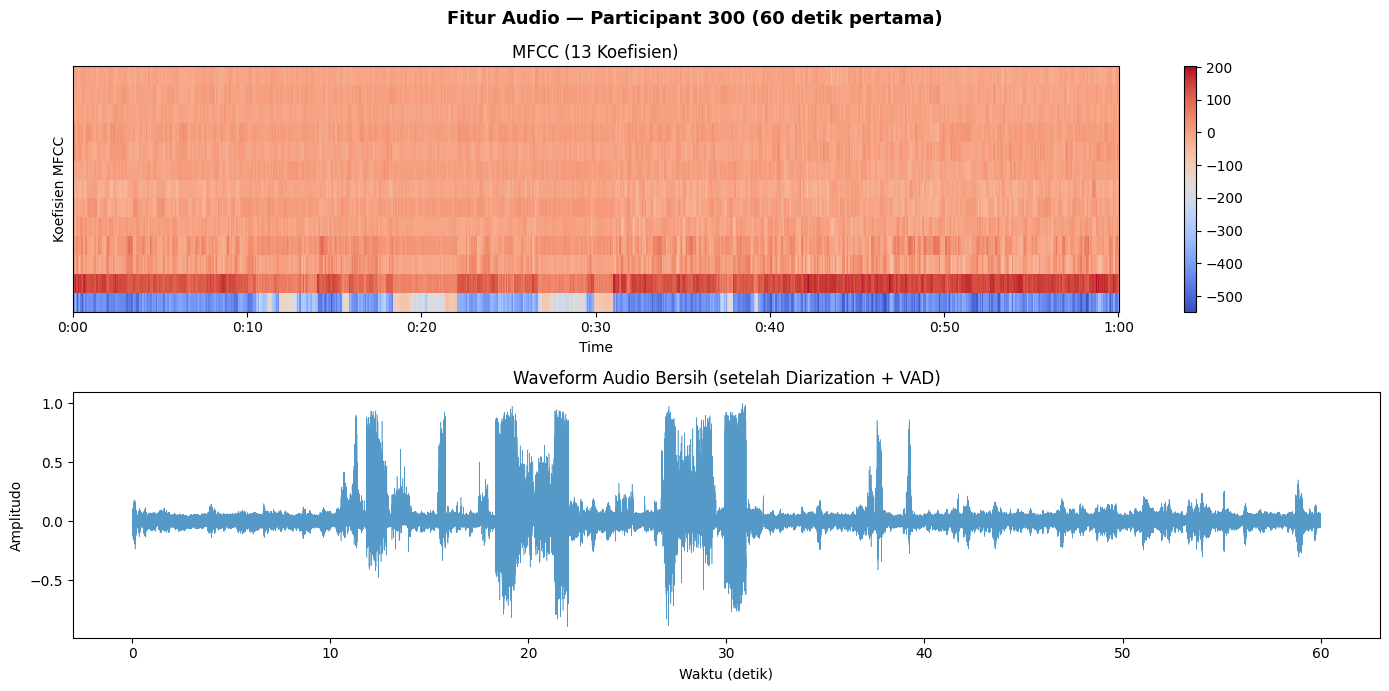

Visualisasi tersimpan.

Jumlah fitur diekstrak: 114

Sample fitur (10 pertama):
  mfcc_1_mean                   : -378.7900
  mfcc_1_std                    : 112.3730
  mfcc_1_min                    : -547.9073
  mfcc_1_max                    : -53.1680
  mfcc_1_p25                    : -449.0034
  mfcc_1_p75                    : -361.7938
  mfcc_2_mean                   : 115.9838
  mfcc_2_std                    : 38.9936
  mfcc_2_min                    : 21.8531
  mfcc_2_max                    : 202.1458


In [6]:
df_meta  = pd.read_csv(META_PATH)
df_valid = df_meta[(df_meta['complete'] == True) & df_meta['phq8_score'].notna()].copy()

DEMO_PID    = 300
DEMO_FOLDER = os.path.join(DAIC_DIR, f"{DEMO_PID}_P")

print(f"Memuat audio bersih partisipan {DEMO_PID}...")
y_demo = load_and_preprocess(DEMO_PID, DEMO_FOLDER)

if y_demo is not None:
    print(f"Durasi audio bersih: {len(y_demo)/TARGET_SR:.1f} detik")

    # Ambil 60 detik pertama untuk visualisasi
    y_viz = y_demo[:TARGET_SR * 60]

    mfccs_demo = librosa.feature.mfcc(y=y_viz, sr=TARGET_SR, n_mfcc=N_MFCC,
                                        n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    fig.suptitle(f'Fitur Audio — Participant {DEMO_PID} (60 detik pertama)', fontsize=13, fontweight='bold')

    # MFCC Heatmap
    img = librosa.display.specshow(mfccs_demo, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                    x_axis='time', ax=axes[0], cmap='coolwarm')
    axes[0].set_ylabel('Koefisien MFCC')
    axes[0].set_title('MFCC (13 Koefisien)')
    fig.colorbar(img, ax=axes[0])

    # Waveform
    t = np.linspace(0, len(y_viz)/TARGET_SR, len(y_viz))
    axes[1].plot(t, y_viz, color='#2980b9', linewidth=0.4, alpha=0.8)
    axes[1].set_xlabel('Waktu (detik)')
    axes[1].set_ylabel('Amplitudo')
    axes[1].set_title('Waveform Audio Bersih (setelah Diarization + VAD)')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'p3_feature_demo.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Visualisasi tersimpan.")

    # Ekstrak dan tampilkan fitur
    demo_feats = extract_features(y_demo, TARGET_SR)
    print(f"\nJumlah fitur diekstrak: {len(demo_feats)}")
    print("\nSample fitur (10 pertama):")
    for k, v in list(demo_feats.items())[:10]:
        print(f"  {k:<30}: {v:.4f}")
else:
    print("Gagal memuat audio demo.")


## 3.5 — Batch Ekstraksi Seluruh Partisipan
Menjalankan ekstraksi fitur untuk semua partisipan yang valid.
Proses ini mungkin memakan waktu 10–30 menit tergantung spesifikasi mesin.


In [7]:
print("="*60)
print("Memulai Batch Ekstraksi Fitur DAIC-WOZ")
print("="*60)
print(f"Total partisipan: {len(df_valid)}\n")

dataset_rows  = []
failed_pids   = []

for idx, (_, row) in enumerate(df_valid.iterrows()):
    pid   = int(row['participant_id'])
    fpath = row['folder_path']

    # Progress indicator
    if (idx + 1) % 10 == 0 or idx == 0:
        print(f"  [{idx+1}/{len(df_valid)}] Memproses PID {pid}...", flush=True)

    # Load + preprocess
    y = load_and_preprocess(pid, fpath)
    if y is None or len(y) < TARGET_SR:  # minimal 1 detik audio
        print(f"  [SKIP] PID {pid}: audio terlalu pendek atau gagal load")
        failed_pids.append(pid)
        continue

    # Ekstraksi fitur
    try:
        feats = extract_features(y, TARGET_SR)
        feats['participant_id'] = pid
        feats['phq8_score']     = row['phq8_score']
        feats['label_3kelas']    = int(row['label_3kelas'])
        feats['severity']       = row['severity']
        dataset_rows.append(feats)
    except Exception as e:
        print(f"  [ERROR] PID {pid}: {e}")
        failed_pids.append(pid)

print(f"\n{'='*60}")
print(f"Selesai! Berhasil: {len(dataset_rows)} | Gagal: {len(failed_pids)}")
if failed_pids:
    print(f"PID gagal: {failed_pids}")


Memulai Batch Ekstraksi Fitur DAIC-WOZ
Total partisipan: 189

  [1/189] Memproses PID 300...
  [10/189] Memproses PID 309...
  [20/189] Memproses PID 319...
  [30/189] Memproses PID 329...
  [40/189] Memproses PID 339...
  [50/189] Memproses PID 350...
  [60/189] Memproses PID 360...
  [70/189] Memproses PID 370...
  [80/189] Memproses PID 380...
  [90/189] Memproses PID 390...
  [100/189] Memproses PID 402...
  [SKIP] PID 406: audio terlalu pendek atau gagal load
  [110/189] Memproses PID 412...
  [120/189] Memproses PID 422...
  [130/189] Memproses PID 432...
  [140/189] Memproses PID 442...
  [150/189] Memproses PID 452...
  [160/189] Memproses PID 463...
  [170/189] Memproses PID 473...
  [180/189] Memproses PID 483...

Selesai! Berhasil: 188 | Gagal: 1
PID gagal: [406]


## 3.6 — Simpan Feature Matrix ke CSV


In [8]:
df_features = pd.DataFrame(dataset_rows)

# Susun ulang kolom: metadata di depan, fitur di belakang
meta_cols = ['participant_id', 'phq8_score', 'label_3kelas', 'severity']
feat_cols = [c for c in df_features.columns if c not in meta_cols]
df_features = df_features[meta_cols + feat_cols]

OUTPUT_FEAT = os.path.join(PROCESSED_DIR, 'daic_features_raw.csv')
df_features.to_csv(OUTPUT_FEAT, index=False)

print(f"\nFeature matrix tersimpan: {OUTPUT_FEAT}")
print(f"Shape: {df_features.shape}")
print(f"  Jumlah partisipan : {df_features.shape[0]}")
print(f"  Jumlah fitur      : {len(feat_cols)}")
print(f"\nSample fitur pertama:")
print(df_features[meta_cols].head(10).to_string(index=False))



Feature matrix tersimpan: d:\repositories\menthealth-ml\dataset\processed\daic_features_raw.csv
Shape: (188, 118)
  Jumlah partisipan : 188
  Jumlah fitur      : 114

Sample fitur pertama:
 participant_id  phq8_score  label_3kelas         severity
            300          14             1 Kecemasan (5-14)
            301           0             0     Stress (0-4)
            302           5             1 Kecemasan (5-14)
            303          14             1 Kecemasan (5-14)
            304           8             1 Kecemasan (5-14)
            305          13             1 Kecemasan (5-14)
            306          10             1 Kecemasan (5-14)
            307           0             0     Stress (0-4)
            308          11             1 Kecemasan (5-14)
            309           0             0     Stress (0-4)


## 3.7 — Visualisasi: Distribusi Fitur per Kelas
Membandingkan distribusi fitur kunci antara partisipan Depresi vs Non-Depresi.


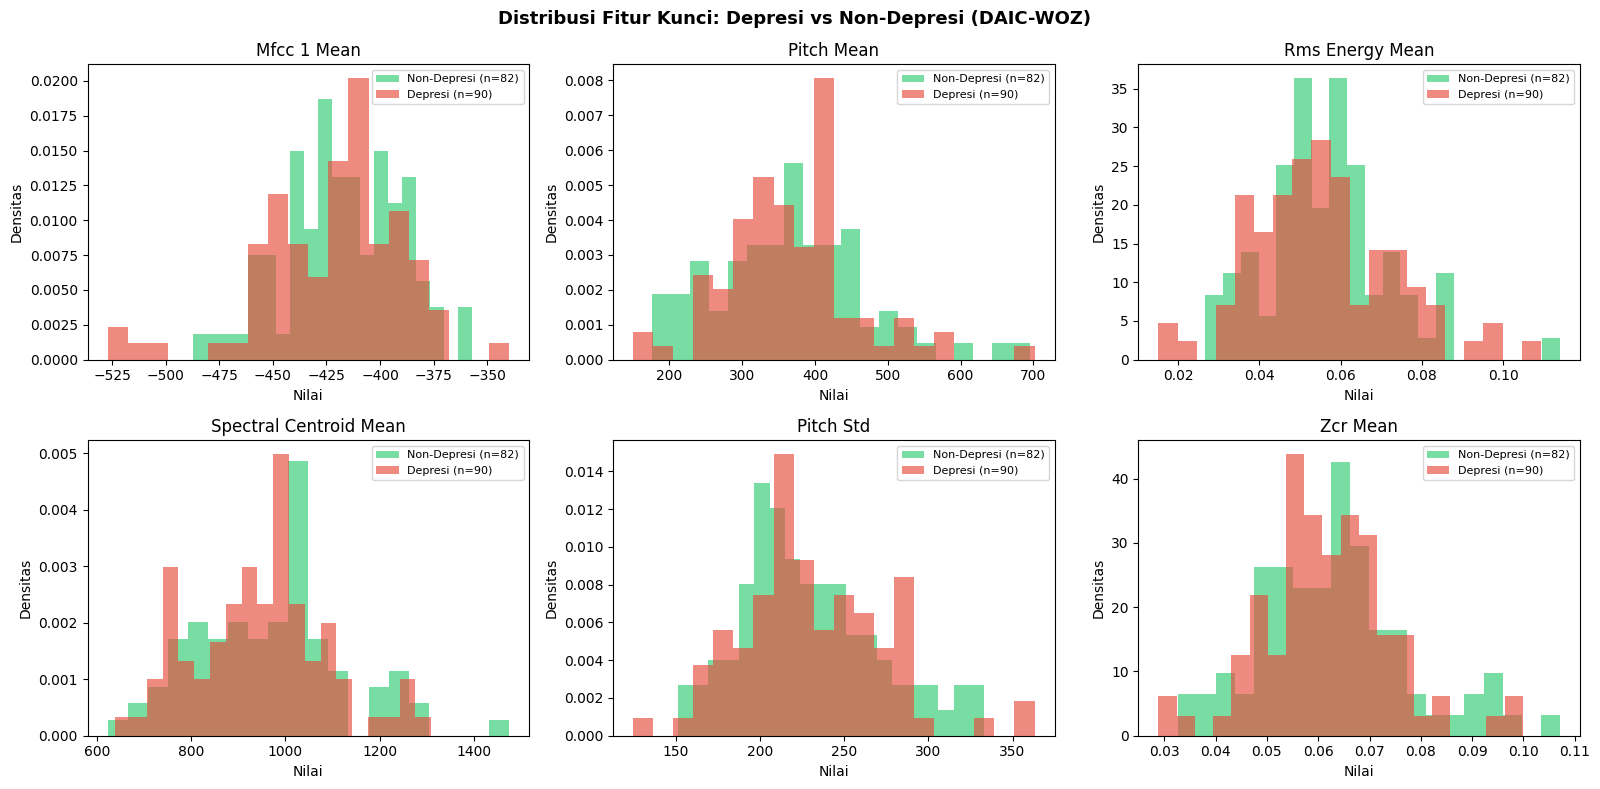

Visualisasi distribusi fitur tersimpan.


In [9]:
key_features = ['mfcc_1_mean', 'pitch_mean', 'rms_energy_mean',
                'spectral_centroid_mean', 'pitch_std', 'zcr_mean']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribusi Fitur Kunci: Depresi vs Non-Depresi (DAIC-WOZ)',
             fontsize=13, fontweight='bold')

df_dep  = df_features[df_features['label_3kelas'] == 1]
df_ndep = df_features[df_features['label_3kelas'] == 0]

for ax, feat in zip(axes.flatten(), key_features):
    ax.hist(df_ndep[feat].dropna(), bins=20, alpha=0.65,
            color='#2ecc71', label=f'Non-Depresi (n={len(df_ndep)})', density=True)
    ax.hist(df_dep[feat].dropna(),  bins=20, alpha=0.65,
            color='#e74c3c', label=f'Depresi (n={len(df_dep)})', density=True)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'p3_feature_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi distribusi fitur tersimpan.")